In [59]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from pathfinding.core.grid import Grid
from pathfinding.finder.a_star import AStarFinder
from pathfinding.core.diagonal_movement import DiagonalMovement
from RRAM import Constants as cte

In [60]:
# Estado inicial de la simulación reset para las vacantes

with open(f'Results/Last_Configuration_forming_0.pkl', 'rb') as file:
    # Carga el contenido del archivo
    initial_configuration = pickle.load(file)

In [61]:
import numpy as np


def all_paths(configuration_matrix: np.ndarray) -> list:
    # obtengo las dimensiones de la matriz
    _, Ejey = configuration_matrix.shape

    # Lista para almacenar todos los caminos
    all_paths_list = []

    # Compruebo si hay trampas en la primera y última columna
    if 1 in configuration_matrix[:, 0] and 1 in configuration_matrix[:, -1]:
        # obtengo las posiciones de los 1 en la primera columna
        start = np.where(configuration_matrix[:, 0] == 1)[0]

        # Creo la lista de nodos de inicio sabiendo que todos los nodos de inicio están en la primera columna
        start = [(i, 0) for i in start]

        # obtengo las posiciones de los 1 en la última columna
        end = np.where(configuration_matrix[:, -1] == 1)[0]

        for k in [1, 2]:
            # obtengo las posiciones de los 1 en la última columna
            end = np.where(configuration_matrix[:, -k] == 1)[0]

            # Creo la lista de nodos de fin sabiendo que todos los nodos de fin están en la última columna en forma de grid node
            end = [(i, Ejey - k) for i in end]

            # Recorro los nodos de inicio y fin para ver si hay camino
            finder = AStarFinder(diagonal_movement=DiagonalMovement.never)

            for i in start:
                for j in end:
                    grid = Grid(matrix=configuration_matrix)

                    node_start = grid.node(i[1], i[0])
                    node_end = grid.node(j[1], j[0])

                    path, runs = finder.find_path(node_start, node_end, grid)
                    if len(path) > 0:
                        # Convert path to a numpy array of tuples
                        path_tuples = np.array([(node.x, node.y) for node in path])
                        all_paths_list.append(path_tuples)

    return all_paths_list


# Uso de la función con la matriz de configuración inicial
percolation_paths = all_paths(initial_configuration)

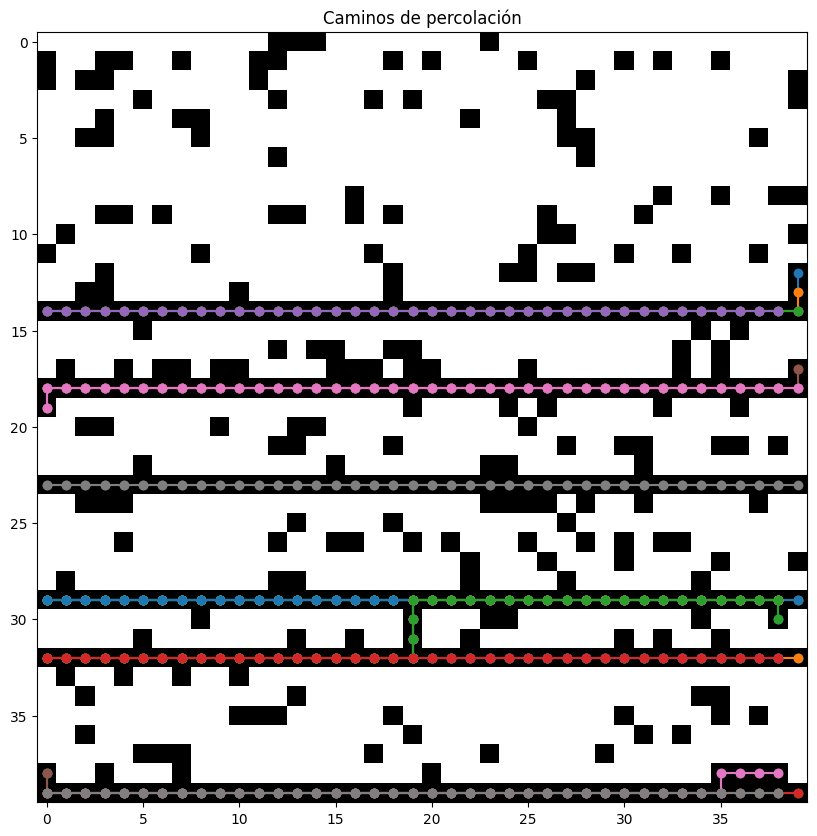

In [62]:
def plot_percolation_paths(configuration_matrix: np.ndarray, paths: list):
    plt.figure(figsize=(10, 10))
    plt.imshow(configuration_matrix, cmap='Greys', interpolation='none')

    for path in paths:
        path = np.array(path)
        plt.plot(path[:, 0], path[:, 1], marker='o')

    plt.title('Caminos de percolación')
    plt.show()


# Uso de la función con la matriz de configuración inicial y los caminos de percolación
plot_percolation_paths(initial_configuration, percolation_paths)

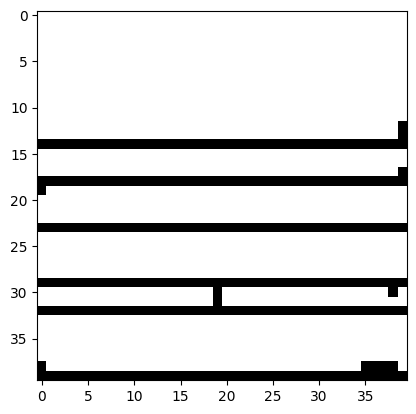

In [63]:
def generate_resitence_matrix(configuration_matrix: np.ndarray, paths: list) -> np.ndarray:
    # Crear una matriz de ceros del mismo tamaño que la configuración inicial
    percolation_matrix = np.zeros_like(configuration_matrix)

    # Iterar sobre cada camino de percolación y marcar las posiciones en la matriz
    for path in paths:
        for (x, y) in path:
            percolation_matrix[y, x] = 1

    return percolation_matrix


# Generar la matriz de percolación
resistence_matrix = generate_resitence_matrix(initial_configuration, percolation_paths)

plt.imshow(resistence_matrix, cmap='Greys', interpolation='none')

In [64]:
def OmhCurrent(potential: float, config_state: np.array, **kwargs) -> float:
    """
    Calculates the Ohmic current based on the given parameters.

    Parameters:
    - DDP (float): The voltage difference across the circuit.
    - config_state (np.array): The configuration state of the circuit.
    - ohm_resistence (float): The default resistance value.

    Returns:
    - float: The calculated Ohmic current.
    """

    # Obtengo los valores de las constantes si las estoy pasando como argumentos
    if kwargs:
        # Obtengo el valor de las constantes que necesita la función
        ohm_resistence = float(kwargs.get('ohm_resistence'))
    else:
        ohm_resistence = 2

    # Initialize total resistance
    total_resistance = 0
    parallel_resistance = 0

    # Sobre cada columna de la matriz
    for row in config_state.T:
        # Se calcula la resistencia paralela de los elementos de la columna
        num_resistence = sum(row)
        for i in range(num_resistence):
            parallel_resistance += 1 / ohm_resistence

        # Se suma la resistencia paralela a la resistencia total
        total_resistance += parallel_resistance

    # Se calcula la corriente Ohmica
    return potential / total_resistance

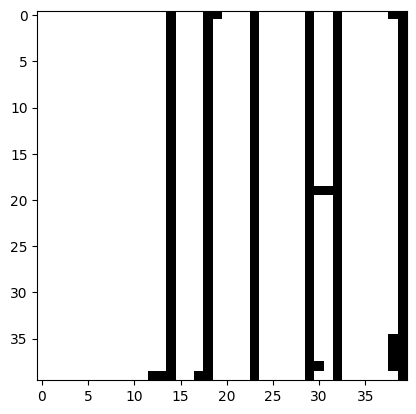

In [65]:
voltaje = 1

plt.imshow(resistence_matrix.T, cmap='Greys', interpolation='none')

In [66]:
resistencia = OmhCurrent(voltaje, resistence_matrix, ohm_resistence=2)

print(f'La resistencia total es: {resistencia}')

La resistencia total es: 0.00039517881841533294
